# 13 &middot; Outline Areas: the shoelace formula, its gradient, and its Hessian

A **closed outline** (or *chamber*) is a loop of edges through 2D vertices. simkit measures the
**signed area** each loop encloses with `outline_areas` and differentiates it with
`outline_areas_gradient` and `outline_areas_hessian`. We check the area on shapes we can measure by
hand, see why the loop's orientation sets its sign, follow the gradient to inflate a star, and verify
both derivatives against finite differences.

Imports, and every tunable parameter of this notebook.

In [1]:
%matplotlib inline
import os
import numpy as np
import matplotlib.pyplot as plt

import simkit
import utils

NOTEBOOK = "013_outline_areas"                                     # this file's name
RESULTS_DIR = simkit.filesystem.notebook_results_path(NOTEBOOK)    # results/013_outline_areas/
MEDIA_DIR = "media"                                                # tracked copies for the website
# 1 · known areas and the shoelace fan
N_GON = 8                         # sides of the regular test polygon
R_GON = 1.0                       # its radius
PENTAGON = np.array([[0.0, 0.0], [2.0, -0.3], [2.4, 1.1],
                     [1.0, 2.0], [-0.5, 1.2]])        # irregular CCW pentagon (fan picture, derivative checks)
FAN_SHIFT = np.array([0.8, 0.6])  # moves the pentagon off the origin so some fan triangles are negative
N_SIDES_SWEEP = np.unique(np.round(np.logspace(np.log10(3), np.log10(2000), 40)).astype(int))  # n-gon sizes
# 2 · orientation
RECT_W, RECT_H = 1.6, 1.0         # rectangle for the winding test
FLIP_HEIGHTS = np.linspace(-1.0, 1.0, 81)   # top-edge heights swept through the degenerate A = 0 loop
# 3 · gradient ascent on a star
STAR_POINTS = 10                  # star tips (the loop has 2 * STAR_POINTS vertices)
STAR_R_OUT, STAR_R_IN = 1.0, 0.42 # tip and notch radii
DT = 0.08                         # gradient-ascent step size
N_STEPS = 90                      # gradient-ascent steps (video has N_STEPS + 1 frames)
FPS = 20                          # video frame rate
# 4 · finite-difference checks
FD_H_GRAD = 1e-6                  # central-difference step for the gradient
FD_H_HESS = 1e-3                  # central-difference step for the Hessian
SEED = 0                          # random pose for the "Hessian is constant" check
# plot colors
POS_C, NEG_C, EDGE_C = "#2a9d8f", "#e76f51", "#264653"

## 1 &middot; Known areas

The signed area of a closed loop with edges $E$ is the shoelace (Gauss) formula below. We evaluate it
with `simkit.outline_areas` (edges from `simkit.closed_polyline`) on a right triangle ($A=\tfrac12$), a
unit square ($A=1$) and a regular $n$-gon of radius $r$ ($A=\tfrac12 n r^2\sin(2\pi/n)$); each panel's
title compares the two, and they agree to every printed digit.

$$A = \tfrac{1}{2} \sum_{(i,j)\in E} \big(x_i\, y_j - x_j\, y_i\big)$$

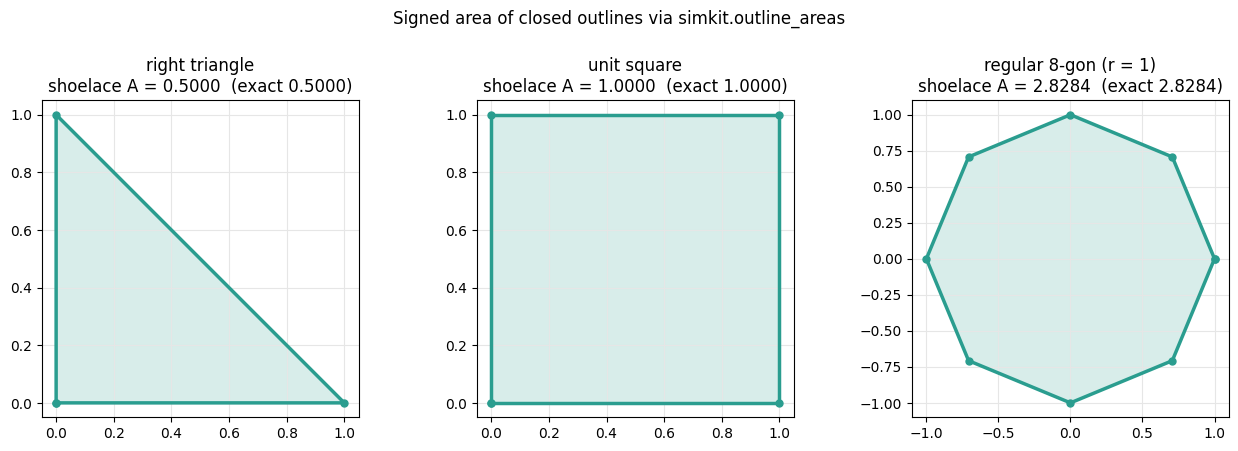

In [2]:
shapes = [
    ("right triangle", np.array([[0.0, 0.0], [1.0, 0.0], [0.0, 1.0]]), 0.5),
    ("unit square", np.array([[0.0, 0.0], [1.0, 0.0], [1.0, 1.0], [0.0, 1.0]]), 1.0),
    (f"regular {N_GON}-gon (r = {R_GON:g})", utils.regular_polygon(N_GON, R_GON),
     0.5 * N_GON * R_GON ** 2 * np.sin(2 * np.pi / N_GON)),
]

fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
for ax, (name, X, exact) in zip(axes, shapes):
    E = simkit.closed_polyline(X)
    A = simkit.outline_areas(X, [E])[0]
    utils.draw_closed_outline(ax, X, E, color=POS_C)
    utils.setup_axes(ax, title=f"{name}\nshoelace A = {A:.4f}  (exact {exact:.4f})")
fig.suptitle("Signed area of closed outlines via simkit.outline_areas", y=1.03)
fig.tight_layout()
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "known_areas.png"),
                              copy_to=os.path.join(MEDIA_DIR, "013_known_areas.png"))
plt.show()

Each shoelace term $\tfrac12(x_i y_j - x_j y_i)$ is the signed area of the triangle (origin, $p_i$,
$p_j$). Below, the pentagon used in section 4 is shifted off the origin and each edge's triangle is
coloured by its term: edges that walk counter-clockwise around the origin give positive triangles
(left), edges facing the origin give negative ones (middle), and the overlap outside the pentagon
cancels, leaving exactly its area (right). The printout lists the five terms and confirms that the
shift does not change the area.

terms: [-0.72  1.9   2.63  1.23 -0.63]  sum = 4.4100
outline_areas: shifted 4.4100, unshifted 4.4100


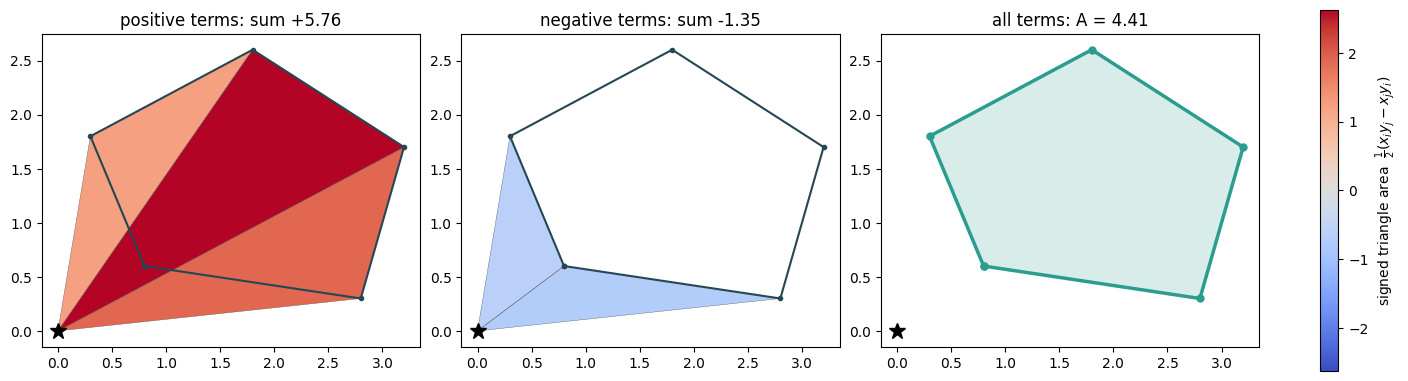

In [3]:
X_p = PENTAGON + FAN_SHIFT
E_p = simkit.closed_polyline(X_p)
i, j = E_p[:, 0], E_p[:, 1]
terms = 0.5 * (X_p[i, 0] * X_p[j, 1] - X_p[j, 0] * X_p[i, 1])     # one shoelace term per edge
A_p = simkit.outline_areas(X_p, [E_p])[0]
A_unshifted = simkit.outline_areas(PENTAGON, [E_p])[0]
print("terms:", np.round(terms, 3), f" sum = {terms.sum():.4f}")
print(f"outline_areas: shifted {A_p:.4f}, unshifted {A_unshifted:.4f}")

X_fan = np.vstack([[0.0, 0.0], X_p])                              # vertex 0 is the origin
T_fan = np.column_stack([np.zeros(len(E_p), dtype=int), E_p + 1])  # triangle (origin, p_i, p_j) per edge
vmax = np.abs(terms).max()
lims = utils.auto_limits([X_fan], pad=0.15)
fig, axes = plt.subplots(1, 3, figsize=(14, 4.6), layout="constrained")
for ax, keep, title in zip(axes, [terms > 0, terms < 0],
                           ["positive terms", "negative terms"]):
    m = utils.plot_scalar_field(ax, X_fan, T_fan[keep], terms[keep], cmap="coolwarm",
                                vmin=-vmax, vmax=vmax, lims=lims, colorbar=False,
                                title=f"{title}: sum {terms[keep].sum():+.2f}")
    utils.draw_closed_outline(ax, X_p, E_p, color=EDGE_C, fill=False, lw=1.5, ms=3)
    ax.plot(0.0, 0.0, "k*", ms=12, zorder=6)
utils.draw_closed_outline(axes[2], X_p, E_p, color=POS_C)
axes[2].plot(0.0, 0.0, "k*", ms=12, zorder=6)
utils.setup_axes(axes[2], *lims, title=f"all terms: A = {A_p:.2f}", grid=False)
fig.colorbar(m, ax=axes.tolist(), shrink=0.8,
             label=r"signed triangle area  $\frac{1}{2}(x_i y_j - x_j y_i)$")
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "shoelace_fan.png"),
                              copy_to=os.path.join(MEDIA_DIR, "013_shoelace_fan.png"))
plt.show()

A regular $n$-gon is a circle we have not finished drawing, so its shoelace area should approach
$\pi r^2$. Taylor-expanding $\sin(2\pi/n)$ predicts the gap $\pi r^2 - A_n \approx
\tfrac{2\pi^3}{3}\, r^2 / n^2$ (dashed); the measured error (dots) lies on it, second order in $1/n$.

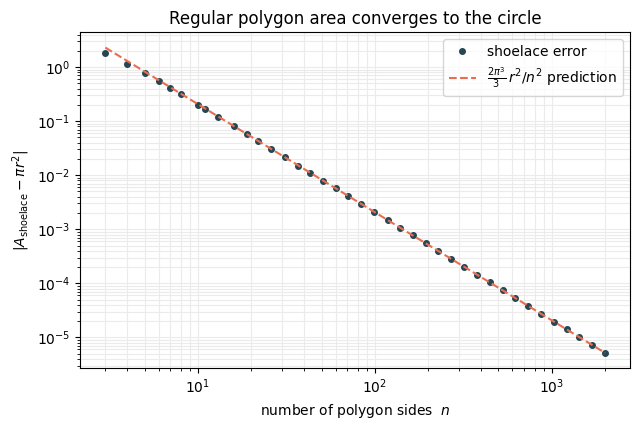

In [4]:
err = []
for n in N_SIDES_SWEEP:
    X_n = utils.regular_polygon(n, R_GON)
    A_n = simkit.outline_areas(X_n, [simkit.closed_polyline(X_n)])[0]
    err.append(abs(A_n - np.pi * R_GON ** 2))

fig, ax = plt.subplots(figsize=(6.5, 4.4))
ax.loglog(N_SIDES_SWEEP, err, "o", color=EDGE_C, ms=4, label="shoelace error")
ax.loglog(N_SIDES_SWEEP, 2 * np.pi ** 3 / 3 * R_GON ** 2 / N_SIDES_SWEEP ** 2, "--", color=NEG_C,
          lw=1.5, label=r"$\frac{2\pi^3}{3}\, r^2/n^2$ prediction")
ax.set_xlabel("number of polygon sides  $n$")
ax.set_ylabel(r"$|A_{\mathrm{shoelace}} - \pi r^2|$")
ax.set_title("Regular polygon area converges to the circle")
ax.grid(True, which="both", color="0.92")
ax.legend()
fig.tight_layout()
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "circle_convergence.png"),
                              copy_to=os.path.join(MEDIA_DIR, "013_circle_convergence.png"))
plt.show()

## 2 &middot; Orientation is the sign of the area

Walking the same loop clockwise instead of counter-clockwise negates every shoelace term, so $A$ flips
sign (left two panels; the arrows show the walk). simkit keeps this sign rather than $|A|$ because the
signed area is a polynomial in the vertex coordinates: its derivatives exist everywhere, including the
degenerate $A = 0$ loop where $|A|$ has a kink. The right panel shows exactly that by sweeping the
rectangle's top edge to height $h$ through zero: $A = W h$ passes straight through, $|A|$ has a corner.

counter-clockwise A = +1.600,  clockwise A = -1.600


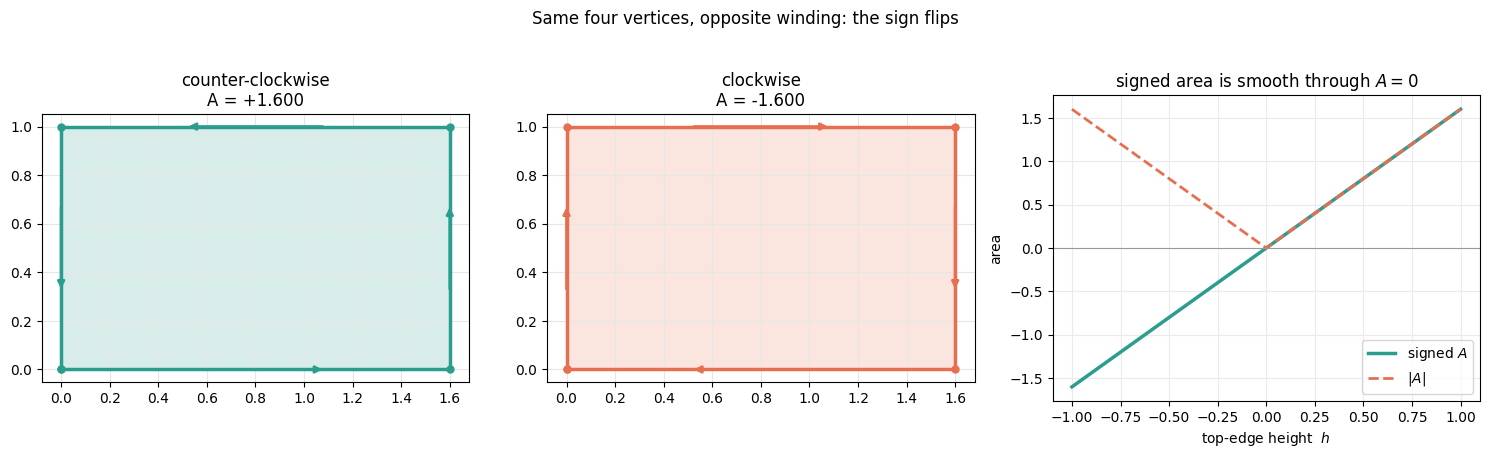

In [5]:
X = np.array([[0.0, 0.0], [RECT_W, 0.0], [RECT_W, RECT_H], [0.0, RECT_H]])
E_ccw = simkit.closed_polyline(X)
E_cw = E_ccw[::-1, ::-1]                 # same loop, walked the other way
A_ccw = simkit.outline_areas(X, [E_ccw])[0]
A_cw = simkit.outline_areas(X, [E_cw])[0]
print(f"counter-clockwise A = {A_ccw:+.3f},  clockwise A = {A_cw:+.3f}")

A_flip = [simkit.outline_areas(np.array([[0.0, 0.0], [RECT_W, 0.0], [RECT_W, h], [0.0, h]]),
                               [E_ccw])[0] for h in FLIP_HEIGHTS]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))
for ax, (E, A, c, label) in zip(axes, [(E_ccw, A_ccw, POS_C, "counter-clockwise"),
                                       (E_cw, A_cw, NEG_C, "clockwise")]):
    utils.draw_closed_outline(ax, X, E, color=c, arrows=True)
    utils.setup_axes(ax, title=f"{label}\nA = {A:+.3f}")
ax = axes[2]
ax.plot(FLIP_HEIGHTS, A_flip, color=POS_C, lw=2.5, label="signed $A$")
ax.plot(FLIP_HEIGHTS, np.abs(A_flip), "--", color=NEG_C, lw=2, label="$|A|$")
ax.axhline(0.0, color="0.6", lw=0.8)
ax.set_xlabel("top-edge height  $h$")
ax.set_ylabel("area")
ax.set_title("signed area is smooth through $A = 0$")
ax.grid(True, color="0.92")
ax.legend()
fig.suptitle("Same four vertices, opposite winding: the sign flips", y=1.03)
fig.tight_layout()
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "orientation_sign.png"),
                              copy_to=os.path.join(MEDIA_DIR, "013_orientation_sign.png"))
plt.show()

## 3 &middot; The gradient inflates the shape

`area_system` wraps the three simkit calls in the energy / gradient / Hessian triple used throughout
these tutorials, with the area $A(x)$ playing the energy, as a function of the stacked vertex positions
$x = [x_0, y_0, x_1, y_1, \dots]$ (tutorial 15 turns $-pA$ into a pneumatic pressure energy). simkit
returns derivatives over each loop's own vertices in `np.unique(E)` order; our loops visit every vertex,
so that order is the global one.

In [6]:
def area_system(E_loop):
    """Signed area A(x) of the closed loop E_loop, with its gradient and Hessian, in stacked x of shape (2n, 1)."""

    def energy_func(x):
        A = simkit.outline_areas(x.reshape(-1, 2), [E_loop])[0]
        return A

    def gradient_func(x):
        g_A = simkit.outline_areas_gradient(x.reshape(-1, 2), [E_loop])[0].reshape(-1, 1)
        return g_A

    def hessian_func(x):
        H_A = simkit.outline_areas_hessian(x.reshape(-1, 2), [E_loop])[0]
        return H_A

    return energy_func, gradient_func, hessian_func

Differentiating the shoelace formula gives, for vertex $i$ with neighbours $i-1$ and $i+1$, the
expression below: $\nabla_i A$ is the neighbour chord $p_{i+1} - p_{i-1}$ rotated clockwise by
$90^\circ$, so it points along the outward normal with half the chord's length. The figure draws this
field on a 10-point star, coloured by that length: the notches, whose neighbours are two far-apart
tips, get the long arrows. The printout checks the chord formula against `gradient_func`.

$$\frac{\partial A}{\partial x_i} = \tfrac12 (y_{i+1} - y_{i-1}), \qquad
  \frac{\partial A}{\partial y_i} = -\tfrac12 (x_{i+1} - x_{i-1})$$

max |grad_i A - rot(chord_i)/2| = 0.0e+00
|grad_i A| at tips 0.130, at notches 0.309


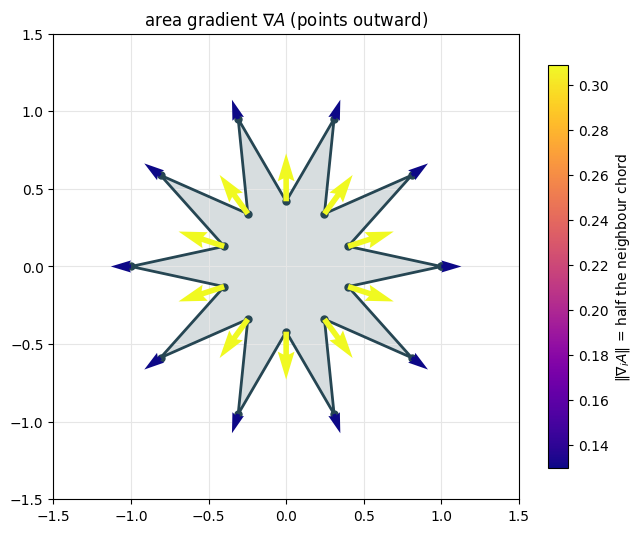

In [7]:
n_star = 2 * STAR_POINTS
X0 = utils.regular_polygon(n_star, np.where(np.arange(n_star) % 2 == 0, STAR_R_OUT, STAR_R_IN))
E_star = simkit.closed_polyline(X0)
energy_func, gradient_func, hessian_func = area_system(E_star)
x0 = X0.reshape(-1, 1)

g0 = gradient_func(x0).reshape(-1, 2)                              # per-vertex dA/dp_i
g_len = np.linalg.norm(g0, axis=1)
chord = np.roll(X0, -1, axis=0) - np.roll(X0, 1, axis=0)           # p_{i+1} - p_{i-1}
print(f"max |grad_i A - rot(chord_i)/2| = {np.abs(g0 - 0.5 * chord[:, ::-1] * [1, -1]).max():.1e}")
print(f"|grad_i A| at tips {g_len[0]:.3f}, at notches {g_len[1]:.3f}")

fig, ax = plt.subplots(figsize=(6.6, 5.6))
utils.draw_closed_outline(ax, X0, E_star, color=EDGE_C, lw=2)
q = ax.quiver(X0[:, 0], X0[:, 1], g0[:, 0], g0[:, 1], g_len, cmap="plasma",
              angles="xy", scale_units="xy", scale=1.0, width=0.012, zorder=5)
fig.colorbar(q, ax=ax, shrink=0.8, label=r"$\|\nabla_i A\|$ = half the neighbour chord")
utils.setup_axes(ax, (-1.5, 1.5), (-1.5, 1.5), title=r"area gradient $\nabla A$ (points outward)")
fig.tight_layout()
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "gradient_field.png"),
                              copy_to=os.path.join(MEDIA_DIR, "013_gradient_field.png"))
plt.show()

Gradient ascent $x \leftarrow x + \Delta t\,\nabla A(x)$ moves every vertex uphill on $A$, so with a
small step the area grows every step. Because $A$ is quadratic, $\nabla A = Hx$ with the constant
Hessian of section 4, and each step multiplies $x$ by $I + \Delta t\,H$. The star mixes just two
eigenvectors of $H$: the regular 20-gon, with eigenvalue $\lambda = \sin(2\pi/20)$, which grows, and the
alternating spikes, with $-\lambda$, which shrink. So the loop rounds out and the area's per-step growth
approaches $(1 + \Delta t\,\lambda)^2$. The cell measures $\lambda$ from `gradient_func`, compares the
growth rates, and reports how round the final loop is (spread of its vertex radii).

In [8]:
states = [X0]
areas = [energy_func(x0)]
x = x0.copy()
for _ in range(N_STEPS):
    x = x + DT * gradient_func(x)                                  # one step straight uphill on A
    states.append(x.reshape(-1, 2))
    areas.append(energy_func(x))
areas = np.array(areas)
print(f"area grew from {areas[0]:.3f} to {areas[-1]:.3f} (grows every step: {np.all(np.diff(areas) > 0)})")

x_reg = utils.regular_polygon(n_star).reshape(-1, 1)               # regular 20-gon: H x_reg = lam x_reg
g_reg = gradient_func(x_reg)
lam = (x_reg.T @ g_reg).item() / (x_reg.T @ x_reg).item()
print(f"lambda = {lam:.4f}  (sin(2 pi/{n_star}) = {np.sin(2 * np.pi / n_star):.4f}), "
      f"eigenvector residual {np.abs(g_reg - lam * x_reg).max():.1e}")
rate = (1 + DT * lam) ** 2
radii = np.linalg.norm(states[-1], axis=1)
print(f"per-step area growth: first {areas[1] / areas[0]:.4f}, last {areas[-1] / areas[-2]:.5f}, "
      f"predicted {rate:.5f}")
print(f"final radius spread (std / mean) = {radii.std() / radii.mean():.2%}")

area grew from 1.298 to 126.337 (grows every step: True)
lambda = 0.3090  (sin(2 pi/20) = 0.3090), eigenvector residual 1.1e-16
per-step area growth: first 1.0699, last 1.05006, predicted 1.05005
final radius spread (std / mean) = 0.48%


The printout confirms the analysis: $\lambda$ equals $\sin(2\pi/20)$, the last step's growth matches the
prediction to $10^{-5}$, and the final radii vary by under 0.5%. The video plays the ascent: the star
(dashed ghost) rounds into a regular 20-gon while, on a log axis, its area climbs every step and merges
onto the predicted rate $(1 + \Delta t\,\lambda)^{2k}$ (dashed, anchored at the last step).

In [9]:
steps = np.arange(N_STEPS + 1)
A_pred = areas[-1] * rate ** (steps - N_STEPS)
pred_label = r"$(1 + \Delta t\,\lambda)^{2k}$ prediction"
fig, anim = utils.animate_outline_trace(
    states, steps, {"area $A$": areas, pred_label: A_pred}, E=E_star, rest=X0, color=POS_C,
    colors={"area $A$": POS_C, pred_label: NEG_C}, dashed=[pred_label], logy=True, fps=FPS,
    xlabel="gradient-ascent step", ylabel="enclosed area  $A$", title="area climbs every step",
    scene_title="inflating the star")
fig.suptitle(r"Following $\nabla A$ inflates the loop and grows its area")
fig.tight_layout()
video = simkit.filesystem.save_animation(anim, os.path.join(RESULTS_DIR, "inflate.mp4"), fps=FPS,
                                         copy_to=os.path.join(MEDIA_DIR, "013_inflate.mp4"))
plt.close(fig)
utils.embed_video(video)

## 4 &middot; Checking the gradient and Hessian against finite differences

We compare `area_system`'s analytic gradient and Hessian on the irregular pentagon against central
finite differences of its area (`simkit.gradient_cfd`, `simkit.hessian_cfd`). The signed area is
bilinear in the coordinates, so the Hessian is a constant matrix of $\pm\tfrac12$ entries that only
couple the $x$ of one endpoint to the $y$ of the other; the printout also confirms that it is identical
at a random pose and that $\nabla A = Hx$ exactly.

max |grad - fd|       = 6.78e-10
max |Hess - fd|       = 5.14e-10
max |H(z) - H(rand)|  = 0.00e+00
max |grad - H z|      = 0.00e+00


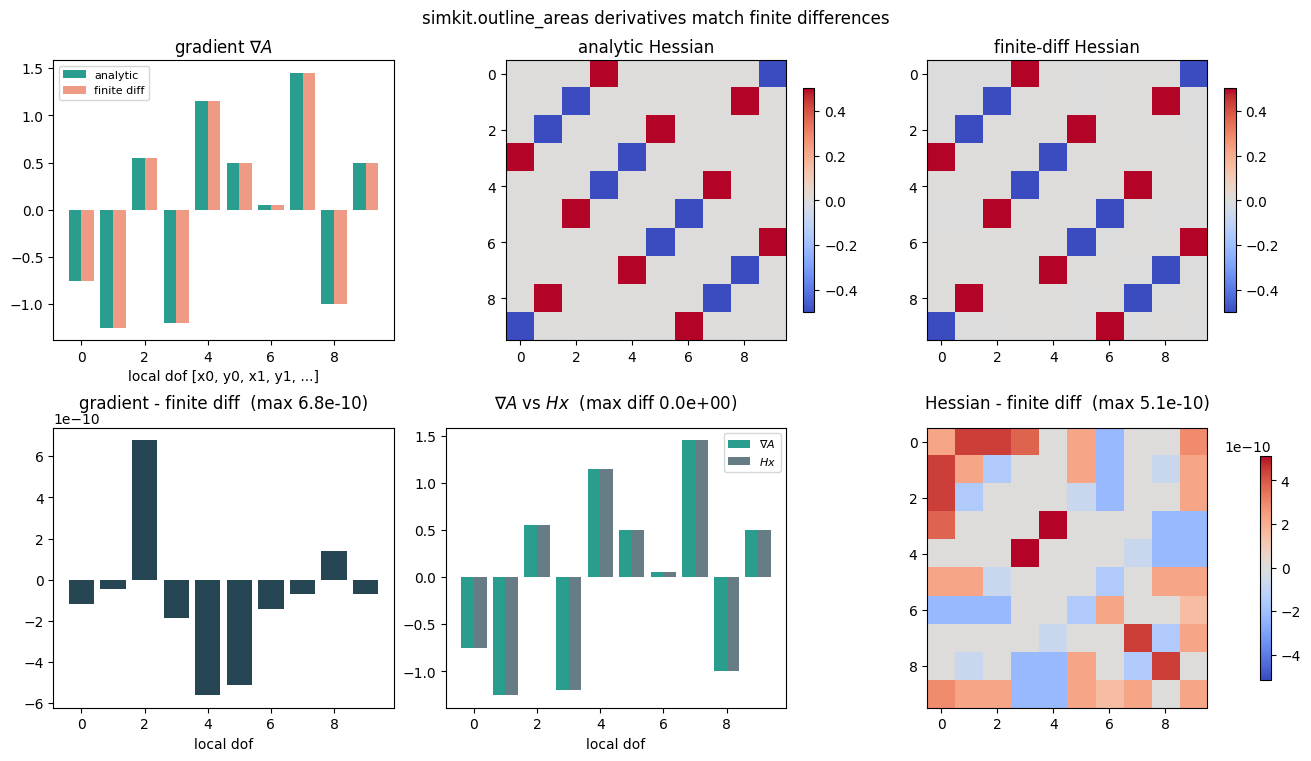

In [10]:
E_pent = simkit.closed_polyline(PENTAGON)
energy_p, gradient_p, hessian_p = area_system(E_pent)
z = PENTAGON.reshape(-1, 1)

g = gradient_p(z).ravel()
g_fd = simkit.gradient_cfd(energy_p, z, FD_H_GRAD)
H = hessian_p(z)
H_fd = simkit.hessian_cfd(energy_p, z, FD_H_HESS)
H_rand = hessian_p(np.random.default_rng(SEED).standard_normal(z.shape))
g_Hz = g - H @ z.ravel()
print(f"max |grad - fd|       = {np.max(np.abs(g - g_fd)):.2e}")
print(f"max |Hess - fd|       = {np.max(np.abs(H - H_fd)):.2e}")
print(f"max |H(z) - H(rand)|  = {np.max(np.abs(H - H_rand)):.2e}")
print(f"max |grad - H z|      = {np.max(np.abs(g_Hz)):.2e}")

fig, axes = plt.subplots(2, 3, figsize=(13, 7.5), layout="constrained")
idx = np.arange(len(g))
ax = axes[0, 0]
ax.bar(idx - 0.2, g, width=0.4, color=POS_C, label="analytic")
ax.bar(idx + 0.2, g_fd, width=0.4, color=NEG_C, alpha=0.7, label="finite diff")
ax.set_title(r"gradient $\nabla A$")
ax.set_xlabel("local dof [x0, y0, x1, y1, ...]")
ax.legend(fontsize=8)
ax = axes[1, 0]
ax.bar(idx, g - g_fd, color=EDGE_C)
ax.set_title(f"gradient - finite diff  (max {np.max(np.abs(g - g_fd)):.1e})", pad=14)
ax.set_xlabel("local dof")
ax = axes[1, 1]
ax.bar(idx - 0.2, g, width=0.4, color=POS_C, label=r"$\nabla A$")
ax.bar(idx + 0.2, H @ z.ravel(), width=0.4, color=EDGE_C, alpha=0.7, label="$Hx$")
ax.set_title(f"$\\nabla A$ vs $Hx$  (max diff {np.max(np.abs(g_Hz)):.1e})", pad=14)
ax.set_xlabel("local dof")
ax.legend(fontsize=8)
vH = np.max(np.abs(H))
for ax, M, title in [(axes[0, 1], H, "analytic Hessian"), (axes[0, 2], H_fd, "finite-diff Hessian")]:
    im = ax.imshow(M, cmap="coolwarm", vmin=-vH, vmax=vH)
    ax.set_title(title)
    fig.colorbar(im, ax=ax, shrink=0.8)
R = H - H_fd
vR = np.max(np.abs(R))
im = axes[1, 2].imshow(R, cmap="coolwarm", vmin=-vR, vmax=vR)
axes[1, 2].set_title(f"Hessian - finite diff  (max {vR:.1e})", pad=14)
fig.colorbar(im, ax=axes[1, 2], shrink=0.8)
fig.suptitle("simkit.outline_areas derivatives match finite differences")
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "derivative_checks.png"),
                              copy_to=os.path.join(MEDIA_DIR, "013_derivative_checks.png"))
plt.show()

All residuals are at the $10^{-10}$ level of finite-difference roundoff, and $\nabla A - Hx$ vanishes to
machine precision: the analytic gradient and constant Hessian are exact.